In [210]:
# Importing Liraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from seaborn import color_palette
from copy import deepcopy
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor

In [211]:
## Display the first 5 rows
df = pd.read_csv('listings.csv')
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,56229,https://www.airbnb.com/rooms/56229,20241211032909,2024-12-12,city scrape,Cosy Double studio in Zone 2 Hammersmith (1),NaN,NaN,https://a0.muscache.com/pictures/3860587/79e73...,216660,...,4.79,4.92,4.71,NaN,f,11,9,1,0,0.84
1,62970,https://www.airbnb.com/rooms/62970,20241211032909,2024-12-12,city scrape,3 Bedrm with Garden off Brick lane refurbd Oct24,Recently renovated (Oct 2024) warehouse conve...,The neighbourhood is fantastic with Brick Lane...,https://a0.muscache.com/pictures/prohost-api/H...,336059,...,4.74,4.63,4.51,NaN,t,1,1,0,0,1.05
2,63948,https://www.airbnb.com/rooms/63948,20241211032909,2024-12-12,city scrape,Cosy Double studio in Zone 2 Hammersmith (4),NaN,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,216660,...,4.78,4.91,4.60,NaN,f,11,9,1,0,1.06
3,66772,https://www.airbnb.com/rooms/66772,20241211032909,2024-12-11,city scrape,Cosy Double studio in Zone 2 Hammersmith (3),NaN,NaN,https://a0.muscache.com/pictures/c71a4e64-97f8...,216660,...,4.77,4.92,4.67,NaN,f,11,9,1,0,1.10
4,69198,https://www.airbnb.com/rooms/69198,20241211032909,2024-12-11,city scrape,Spacious single room in quiet flat,NaN,The flat is situated in a culturally vibrant a...,https://a0.muscache.com/pictures/6073529/f5cf9...,345886,...,4.85,4.62,4.23,NaN,f,1,0,1,0,0.09


In [212]:
## Displaying the data types
df.dtypes

id                                                int64
listing_url                                      object
scrape_id                                         int64
last_scraped                                     object
source                                           object
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 75, dtype: object

In [213]:
# Dropping some unnecessary columns
df.drop(['listing_url', 'id', 'scrape_id', 'last_scraped', 'source', 'host_id', 
         'picture_url', 'name', 'host_since', 'host_url', 'host_name',
         'neighborhood_overview', 'description', 'host_thumbnail_url',
         'host_picture_url','host_about', 'host_verifications','neighbourhood',
         'calendar_last_scraped','first_review', 'last_review', 'host_location'], axis=1, inplace=True)

df.head()

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.79,4.92,4.71,NaN,f,11,9,1,0,0.84
1,within a few hours,100%,100%,NaN,Mid-Beach,16.0,47.0,t,t,Tower Hamlets,...,4.74,4.63,4.51,NaN,t,1,1,0,0,1.05
2,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.78,4.91,4.60,NaN,f,11,9,1,0,1.06
3,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.77,4.92,4.67,NaN,f,11,9,1,0,1.10
4,NaN,NaN,NaN,f,NaN,1.0,1.0,t,t,Haringey,...,4.85,4.62,4.23,NaN,f,1,0,1,0,0.09


In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95144 entries, 0 to 95143
Data columns (total 53 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_response_time                            62709 non-null  object 
 1   host_response_rate                            62709 non-null  object 
 2   host_acceptance_rate                          67888 non-null  object 
 3   host_is_superhost                             93396 non-null  object 
 4   host_neighbourhood                            46317 non-null  object 
 5   host_listings_count                           95137 non-null  float64
 6   host_total_listings_count                     95137 non-null  float64
 7   host_has_profile_pic                          95137 non-null  object 
 8   host_identity_verified                        95137 non-null  object 
 9   neighbourhood_cleansed                        95144 non-null 

In [215]:
df.isnull().sum().sort_values(ascending=False)

license                                         95144
calendar_updated                                95144
neighbourhood_group_cleansed                    95144
host_neighbourhood                              48827
beds                                            32454
host_response_time                              32435
host_response_rate                              32435
bathrooms                                       32400
price                                           32367
host_acceptance_rate                            27256
review_scores_location                          24631
review_scores_value                             24631
review_scores_checkin                           24629
review_scores_communication                     24606
review_scores_accuracy                          24600
review_scores_cleanliness                       24593
review_scores_rating                            24584
reviews_per_month                               24584
bedrooms                    

In [216]:
df.isnull().mean().sort_values(ascending=False) * 100

license                                         100.000000
calendar_updated                                100.000000
neighbourhood_group_cleansed                    100.000000
host_neighbourhood                               51.319053
beds                                             34.110401
host_response_time                               34.090431
host_response_rate                               34.090431
bathrooms                                        34.053645
price                                            34.018961
host_acceptance_rate                             28.647103
review_scores_location                           25.888127
review_scores_value                              25.888127
review_scores_checkin                            25.886025
review_scores_communication                      25.861852
review_scores_accuracy                           25.855545
review_scores_cleanliness                        25.848188
review_scores_rating                             25.8387

In [217]:
df.drop(['neighbourhood_group_cleansed', 'license', 'calendar_updated'], axis=1, inplace=True)

df.isnull().mean().sort_values(ascending=False) * 100

host_neighbourhood                              51.319053
beds                                            34.110401
host_response_time                              34.090431
host_response_rate                              34.090431
bathrooms                                       34.053645
price                                           34.018961
host_acceptance_rate                            28.647103
review_scores_value                             25.888127
review_scores_location                          25.888127
review_scores_checkin                           25.886025
review_scores_communication                     25.861852
review_scores_accuracy                          25.855545
review_scores_cleanliness                       25.848188
review_scores_rating                            25.838729
reviews_per_month                               25.838729
bedrooms                                        12.980325
has_availability                                 4.691836
host_is_superh

In [218]:
# Identifying categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()

print("Categorical Columns:", categorical_columns)
print("Numerical Columns:", numerical_columns)

Categorical Columns: ['host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_neighbourhood', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'amenities', 'price', 'has_availability', 'instant_bookable']
Numerical Columns: ['host_listings_count', 'host_total_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculate

In [219]:
def fill_missing_values(df, columns):
    fill_values = {column: df[column].mean() for column in columns}
    df.fillna(fill_values, inplace=True)

# List of numerical columns to fill missing values
numerical_columns_to_fill = [
    'host_listings_count', 'host_total_listings_count', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 
    'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 
    'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 
    'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating', 
    'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 
    'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 
    'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 
    'calculated_host_listings_count_shared_rooms', 'reviews_per_month'
]

# Fill missing values
fill_missing_values(df, numerical_columns_to_fill)

In [220]:
def fill_missing_categorical_values(df, columns):
    # Check if the column exists in the DataFrame before filling missing values
    fill_values = {column: df[column].mode()[0] for column in columns if column in df.columns and df[column].mode().size > 0}
    df.fillna(fill_values, inplace=True)

# List of categorical columns to fill missing values
categorical_columns_to_fill = [
    'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 
    'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_verifications', 
    'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'property_type', 
    'room_type', 'bathrooms_text', 'amenities', 'price', 'has_availability', 'calendar_last_scraped', 
    'first_review', 'last_review', 'instant_bookable'
]

# Fill missing values
fill_missing_categorical_values(df, categorical_columns_to_fill)

# Print the head of the dataset to verify
df.head()

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.88,4.79,4.92,4.71,f,11,9,1,0,0.84
1,within a few hours,100%,100%,f,Mid-Beach,16.0,47.0,t,t,Tower Hamlets,...,4.80,4.74,4.63,4.51,t,1,1,0,0,1.05
2,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.87,4.78,4.91,4.60,f,11,9,1,0,1.06
3,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.87,4.77,4.92,4.67,f,11,9,1,0,1.10
4,within an hour,100%,100%,f,Hampstead,1.0,1.0,t,t,Haringey,...,4.62,4.85,4.62,4.23,f,1,0,1,0,0.09


In [221]:
# Converting all column names to lowercase and replace the spaces with an underscore "_"
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [222]:
# Removing the dollar sign and comma from the columns of price and service_fee
df['price'] = df['price'].replace({r'\$': '', ',': ''}, regex=True).astype(float)

In [223]:
df.isnull().sum().sort_values(ascending=False)

host_response_time                              0
review_scores_rating                            0
minimum_nights_avg_ntm                          0
maximum_nights_avg_ntm                          0
has_availability                                0
availability_30                                 0
availability_60                                 0
availability_90                                 0
availability_365                                0
number_of_reviews                               0
number_of_reviews_ltm                           0
number_of_reviews_l30d                          0
review_scores_accuracy                          0
host_response_rate                              0
review_scores_cleanliness                       0
review_scores_checkin                           0
review_scores_communication                     0
review_scores_location                          0
review_scores_value                             0
instant_bookable                                0


In [224]:
df.columns

Index(['host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_l

In [225]:
df[['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
    'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms','beds',
    'amenities', 'price', 'minimum_nights', 'maximum_nights','minimum_minimum_nights',
    'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights',
    'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm',
    'number_of_reviews_l30d', 'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness']].head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,...,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness
0,Hammersmith and Fulham,51.49392,-0.22754,Entire rental unit,Entire home/apt,2,1.5,1.5 baths,1.0,1.0,...,2,8,11,22,145,42,1,4.71,4.71,4.67
1,Tower Hamlets,51.52435,-0.06938,Entire condo,Entire home/apt,6,3.0,3 baths,3.0,3.0,...,13,23,53,326,178,3,1,4.52,4.64,4.60
2,Hammersmith and Fulham,51.49547,-0.22864,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,...,0,7,12,149,170,57,1,4.61,4.62,4.69
3,Hammersmith and Fulham,51.49368,-0.22774,Room in aparthotel,Private room,2,1.0,1 private bath,1.0,1.0,...,9,32,45,62,186,44,2,4.65,4.76,4.76
4,Haringey,51.59031,-0.09408,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,...,28,58,88,363,13,0,0,4.46,4.69,4.77


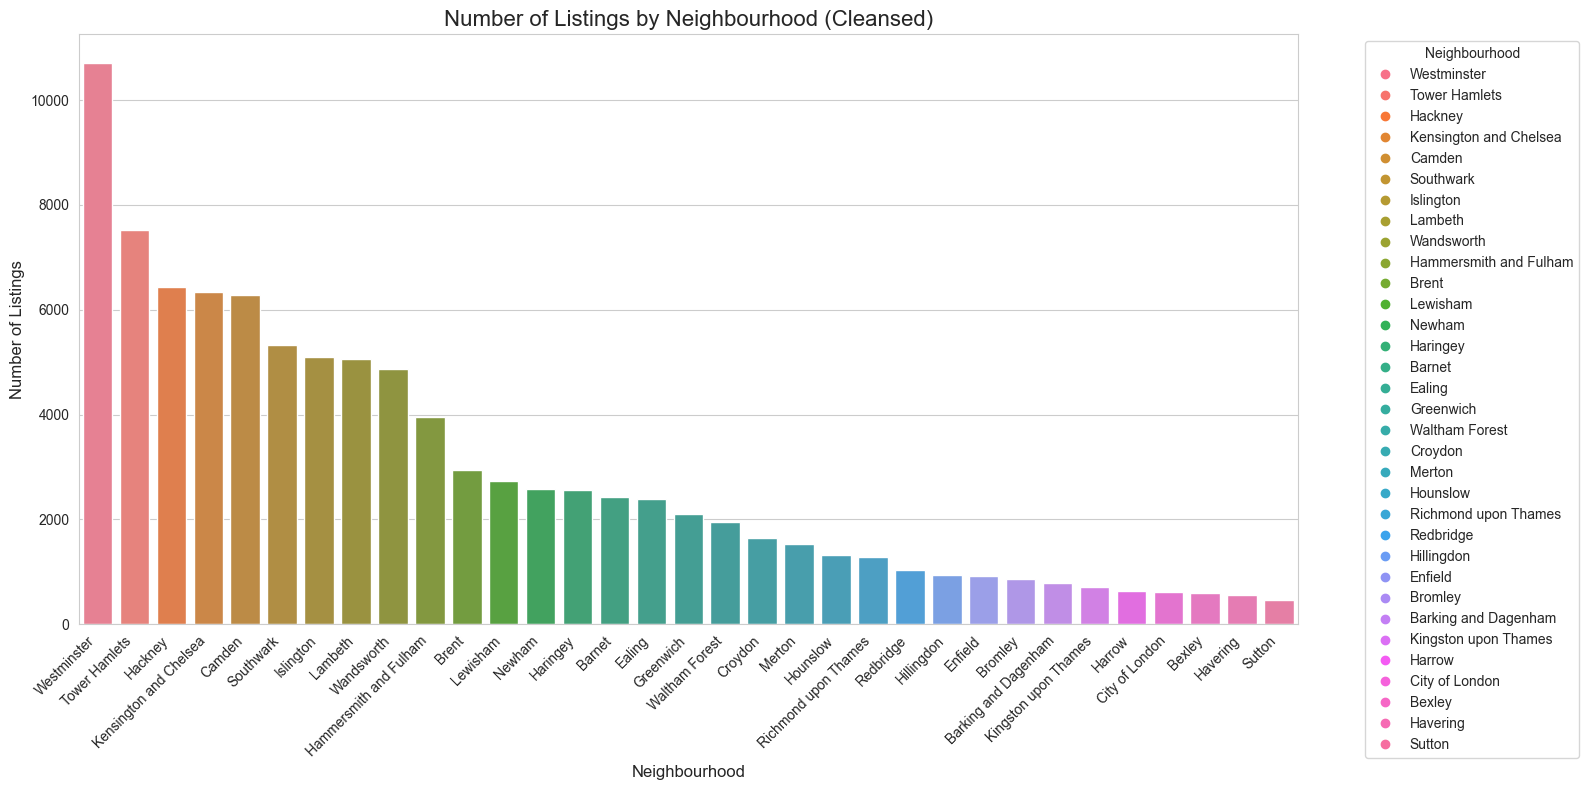

In [226]:
# Count the occurrences of each unique value in 'neighbourhood_cleansed'
neighbourhood_counts = df['neighbourhood_cleansed'].value_counts()

# Generate a color palette with as many colors as there are unique neighbourhoods
colors = color_palette("husl", len(neighbourhood_counts))

# Create a bar plot with seaborn
plt.figure(figsize=(16, 8))  # Increased width for better readability
sns.barplot(x=neighbourhood_counts.index, y=neighbourhood_counts.values, palette=colors, hue=neighbourhood_counts.index, dodge=False, legend=False)

# Add title and labels
plt.title('Number of Listings by Neighbourhood (Cleansed)', fontsize=16)
plt.xlabel('Neighbourhood', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add a legend outside the graph
# Create a legend with both neighborhood names and corresponding colors
handles = [plt.Line2D([0], [0], marker='o', color=color, label=neighbourhood, linestyle='') 
           for color, neighbourhood in zip(colors, neighbourhood_counts.index)]
plt.legend(title="Neighbourhood", handles=handles, loc='upper left', bbox_to_anchor=(1.05, 1))

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

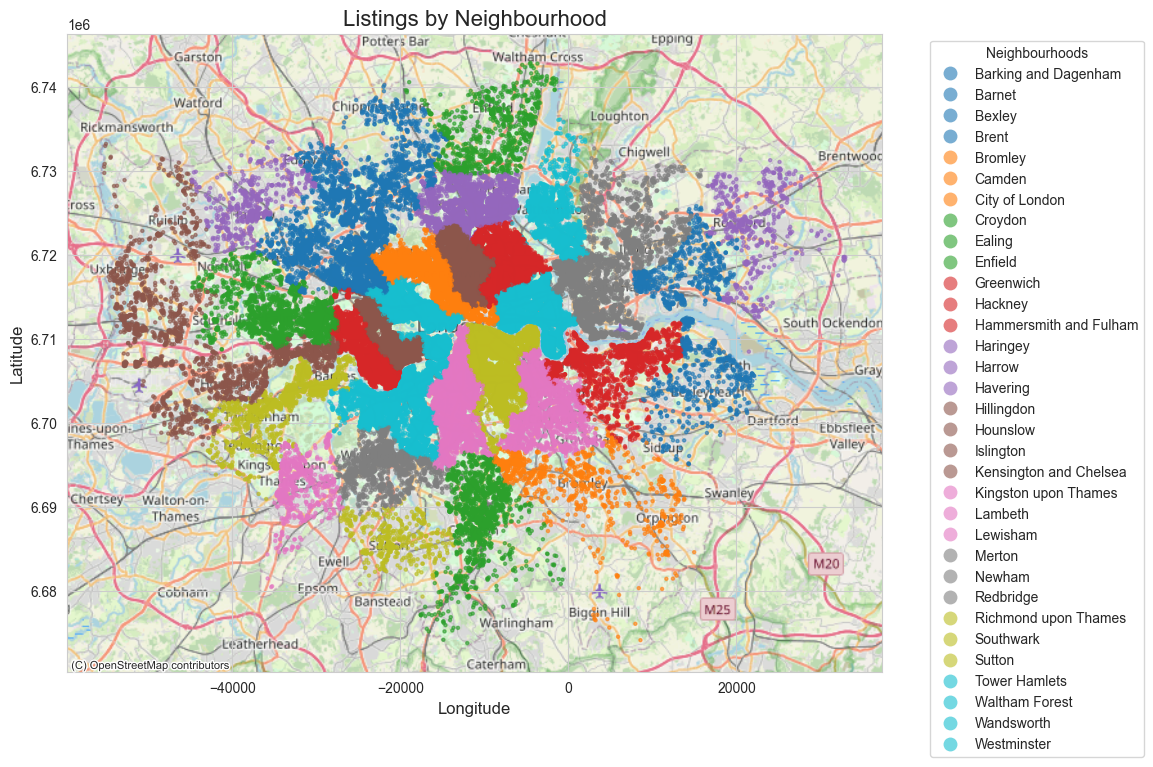

In [227]:
# Create a GeoDataFrame from the DataFrame
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
geo_df = gpd.GeoDataFrame(df, geometry=geometry)

# Set the coordinate reference system (CRS) to WGS84 (EPSG:4326)
geo_df.set_crs(epsg=4326, inplace=True)

# Convert to Web Mercator (EPSG:3857) for compatibility with contextily
geo_df = geo_df.to_crs(epsg=3857)

# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(12, 8))
geo_df.plot(ax=ax, markersize=5, alpha=0.6, column='neighbourhood_cleansed', legend=True)

# Add a basemap using contextily
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Add title and labels
ax.set_title('Listings by Neighbourhood', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Move the legend outside of the graph
legend = ax.get_legend()
if legend:
    legend.set_bbox_to_anchor((1.05, 1))
    legend.set_title("Neighbourhoods")

plt.tight_layout()
plt.show()

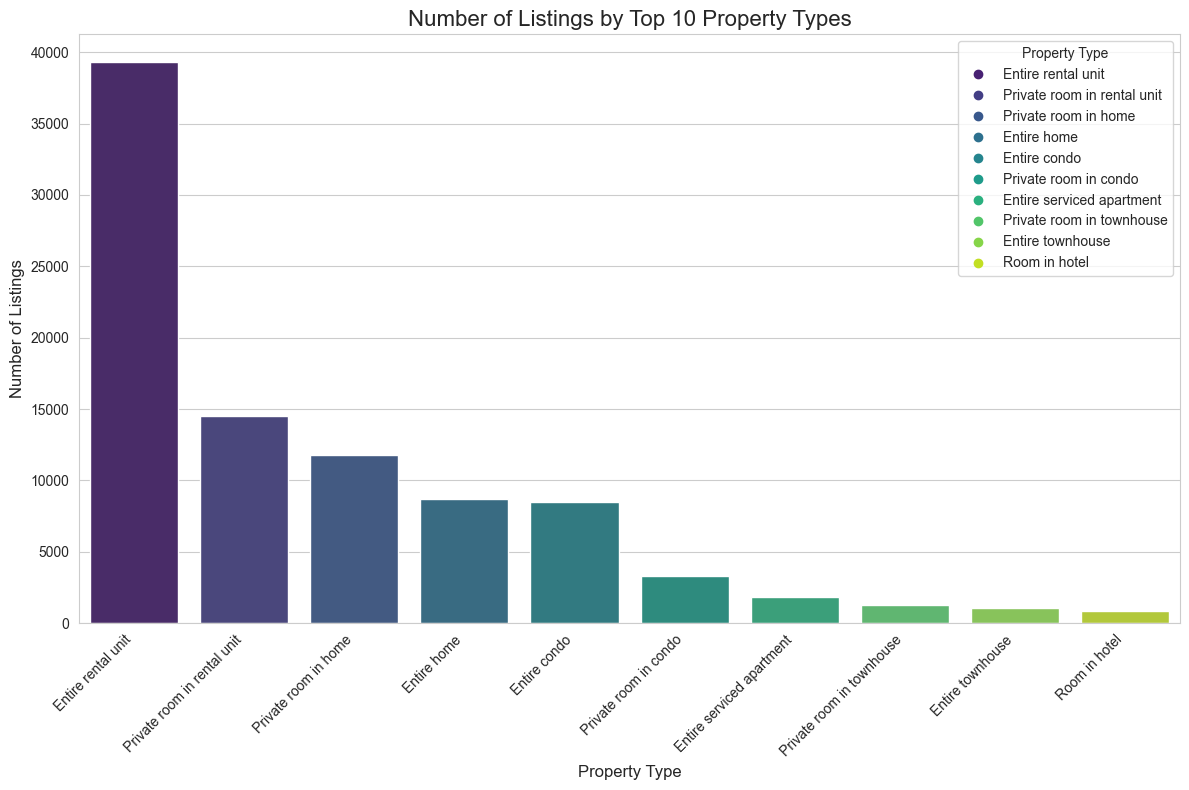

In [228]:
# Ensure "property_type_counts" is defined
property_type_counts = df['property_type'].value_counts()

# Select the top 10 property types
top_property_types = property_type_counts.head(10)

# Create a bar plot with seaborn
plt.figure(figsize=(12, 8))
sns.barplot(x=top_property_types.index, y=top_property_types.values, 
            hue=top_property_types.index, palette="viridis", dodge=False,
            legend=False)

# Add title and labels
plt.title('Number of Listings by Top 10 Property Types', fontsize=16)
plt.xlabel('Property Type', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add legend manually
handles = [plt.Line2D([0], [0], marker='o', color=color, label=ptype, linestyle='') 
           for color, ptype in zip(sns.color_palette("viridis", len(top_property_types)), 
                                   top_property_types.index)]
plt.legend(title="Property Type", handles=handles, loc='upper right')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

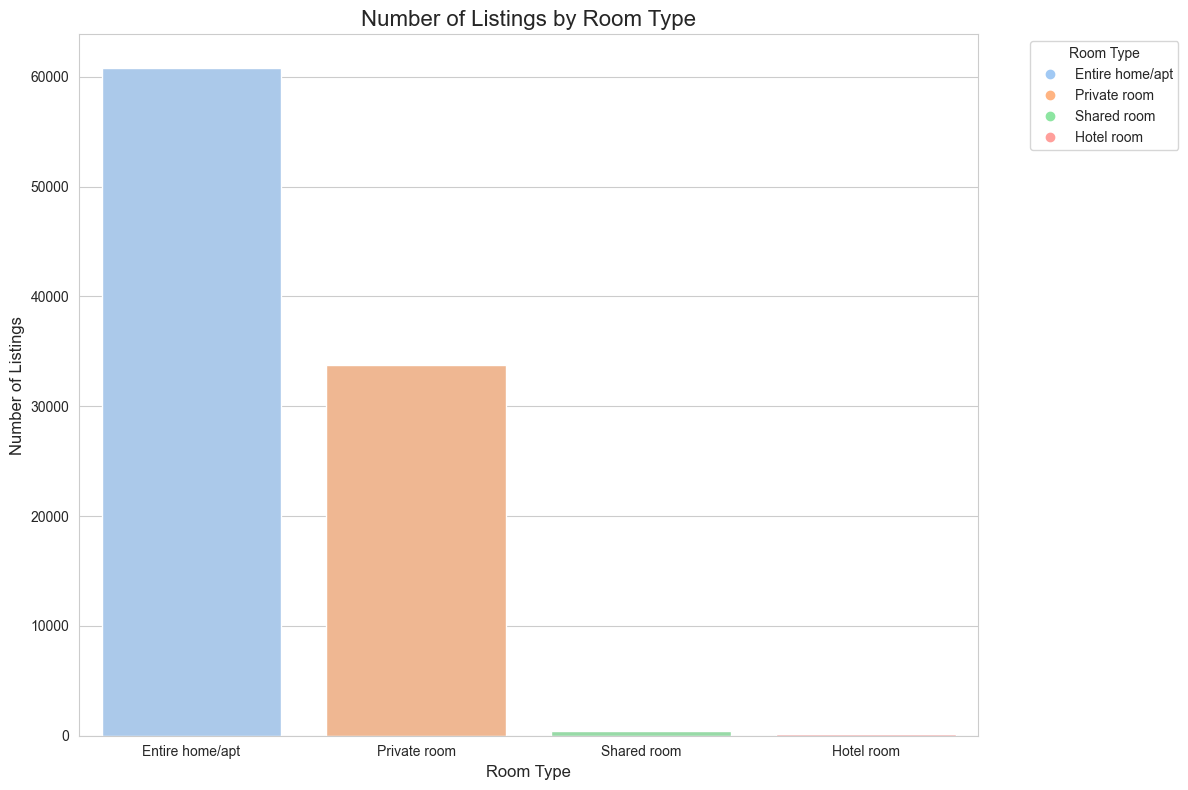

In [229]:
# Count the occurrences of each unique value in 'room_type'
room_type_counts = df['room_type'].value_counts()

# Create a bar plot with seaborn
plt.figure(figsize=(12, 8))
sns.barplot(x=room_type_counts.index, y=room_type_counts.values, hue=room_type_counts.index, palette="pastel", dodge=False)

# Add title and labels
plt.title('Number of Listings by Room Type', fontsize=16)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)

# Create a legend with room types and corresponding colors
handles = [plt.Line2D([0], [0], marker='o', color=color, label=room_type, linestyle='') 
           for color, room_type in zip(sns.color_palette("pastel", len(room_type_counts)), room_type_counts.index)]
plt.legend(title="Room Type", handles=handles, loc='upper left', bbox_to_anchor=(1.05, 1))

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [230]:
df[['bathrooms_text', 'bedrooms','beds', 'amenities', 'price', 'minimum_nights',
    'maximum_nights','minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60',
    'availability_90']].head()

,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90
0,1.5 baths,1.0,1.0,"[""Cooking basics"", ""Fire extinguisher"", ""Dryer...",89.0,5,365,1.0,7.0,365.0,365.0,4.1,365.0,t,2,8,11
1,3 baths,3.0,3.0,"[""Cooking basics"", ""Dryer"", ""Stove"", ""Patio or...",220.0,1,1125,1.0,3.0,2.0,1125.0,2.9,793.7,t,13,23,53
2,1 bath,1.0,1.0,"[""Cooking basics"", ""Fire extinguisher"", ""Dryer...",88.0,3,730,1.0,3.0,730.0,730.0,3.0,730.0,t,0,7,12
3,1 private bath,1.0,1.0,"[""Cooking basics"", ""Fire extinguisher"", ""Stove...",75.0,3,1125,1.0,3.0,1125.0,1125.0,2.8,1125.0,t,9,32,45
4,1 shared bath,1.0,1.0,"[""Wifi"", ""Hot water"", ""Washer"", ""Breakfast"", ""...",53.0,3,730,3.0,3.0,730.0,730.0,3.0,730.0,t,28,58,88


In [231]:
df['bathrooms_text'].unique()

array(['1.5 baths', '3 baths', '1 bath', '1 private bath',
       '1 shared bath', '2 baths', '2.5 baths', '1.5 shared baths',
       'Shared half-bath', '0 shared baths', '2.5 shared baths',
       '0 baths', '2 shared baths', '4 baths', '3 shared baths',
       '3.5 baths', 'Half-bath', '4.5 baths', '5 shared baths',
       '3.5 shared baths', '5 baths', '4 shared baths', '6 baths',
       '5.5 baths', '10 baths', 'Private half-bath', '7 shared baths',
       '8 shared baths', '6.5 baths', '7.5 baths', '10 shared baths',
       '10.5 baths', '4.5 shared baths', '12 baths', '13 baths',
       '16 baths', '7 baths', '5.5 shared baths', '8.5 baths',
       '13 shared baths', '16.5 baths', '12.5 baths', '48 baths',
       '8 baths', '9 baths', '17 baths', '22 baths', '20 baths',
       '12 shared baths', '14 baths', '18 baths', '26 baths',
       '11.5 baths', '15 baths', '6 shared baths', '19.5 baths'],
      dtype=object)

In [232]:
df['bathrooms_text'].value_counts()

bathrooms_text
1 bath               44495
2 baths              12270
1 shared bath        11775
1 private bath        7847
1.5 baths             6289
1.5 shared baths      3076
2.5 baths             2717
3 baths               1639
2 shared baths        1498
3.5 baths              743
Half-bath              379
2.5 shared baths       364
4 baths                327
Shared half-bath       281
0 baths                276
3 shared baths         244
0 shared baths         177
4.5 baths              167
Private half-bath      154
5 baths                111
6 baths                 95
3.5 shared baths        48
5.5 baths               40
4 shared baths          20
4.5 shared baths        18
5 shared baths          11
7 baths                 11
10 shared baths         10
6.5 baths                9
8 baths                  6
5.5 shared baths         5
10 baths                 5
9 baths                  4
8.5 baths                4
6 shared baths           3
20 baths                 2
12.5 baths   

In [233]:
df['host_is_superhost'].value_counts()

host_is_superhost
f    78226
t    16918
Name: count, dtype: int64

In [234]:
df.duplicated().sum()

66

In [235]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [236]:
df.shape

(95078, 50)

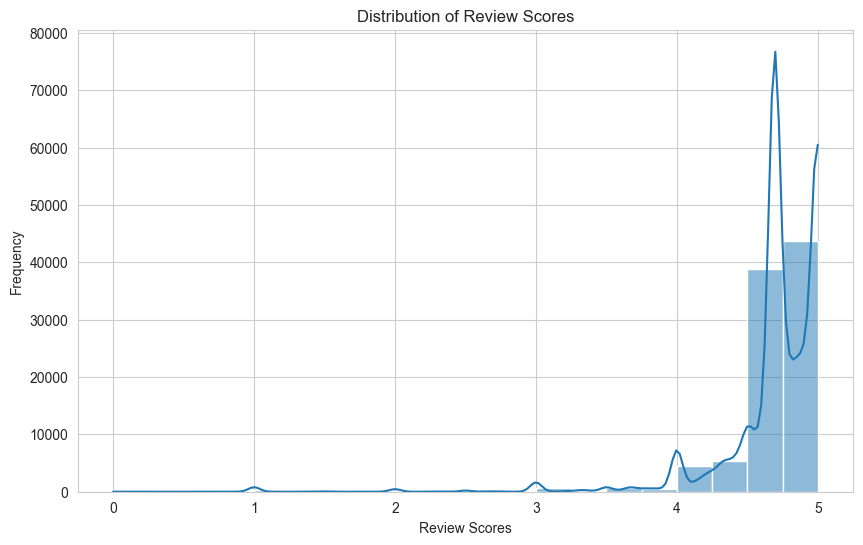

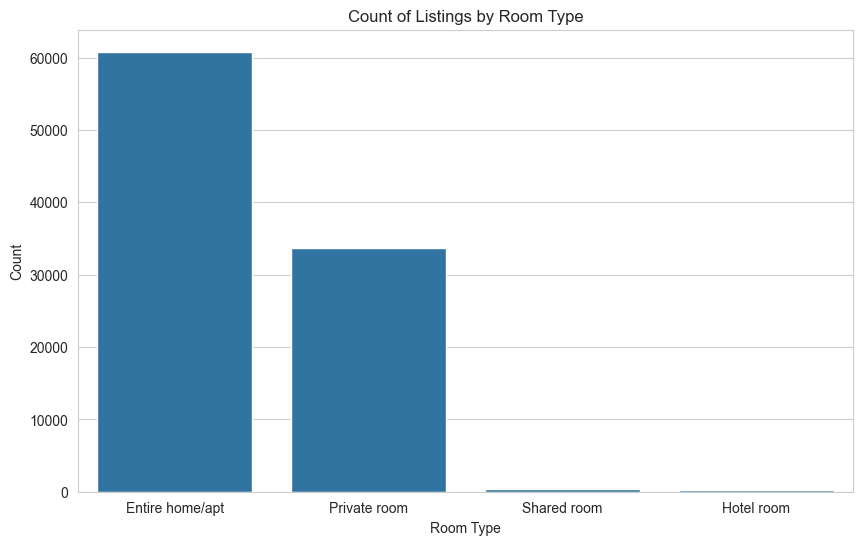

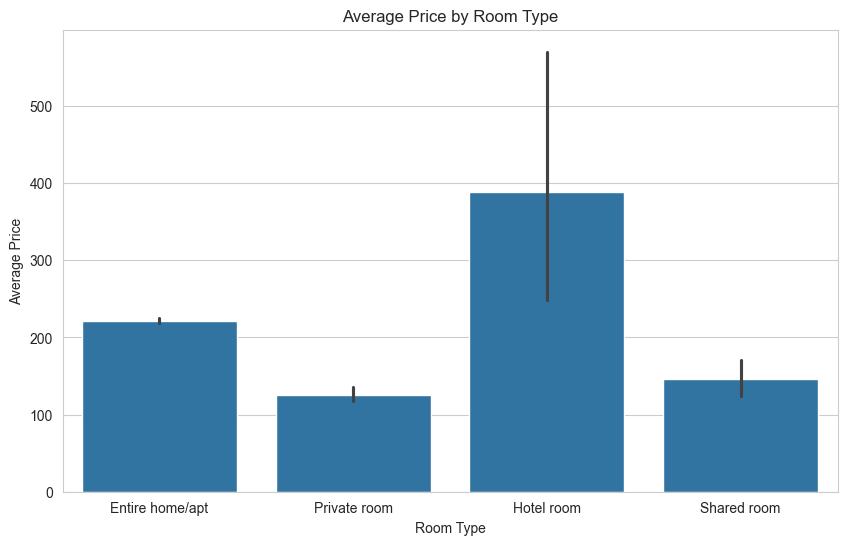

In [237]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Plot the distribution of review scores
plt.figure(figsize=(10, 6))
sns.histplot(df['review_scores_rating'], bins=20, kde=True)
plt.title('Distribution of Review Scores')
plt.xlabel('Review Scores')
plt.ylabel('Frequency')
plt.show()

# Plot the count of listings by room type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='room_type', order=df['room_type'].value_counts().index)
plt.title('Count of Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

# Plot the average price by room type
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='room_type', y=df['price'])
plt.title('Average Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price')
plt.show()

In [238]:
df1 = deepcopy(df)

In [239]:
df1.head()

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.88,4.79,4.92,4.71,f,11,9,1,0,0.84
1,within a few hours,100%,100%,f,Mid-Beach,16.0,47.0,t,t,Tower Hamlets,...,4.80,4.74,4.63,4.51,t,1,1,0,0,1.05
2,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.87,4.78,4.91,4.60,f,11,9,1,0,1.06
3,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.87,4.77,4.92,4.67,f,11,9,1,0,1.10
4,within an hour,100%,100%,f,Hampstead,1.0,1.0,t,t,Haringey,...,4.62,4.85,4.62,4.23,f,1,0,1,0,0.09


In [240]:
df1.columns

Index(['host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_l

In [241]:
df1.dropna(subset=['price'], inplace=True)

In [242]:
# Dropping 'host_neighbourhood','amenities','latitude','longitude'
df1.drop(['host_neighbourhood','amenities','latitude','longitude'], axis=1, inplace=True)
df1.head()

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,within a day,99%,95%,f,11.0,11.0,t,t,Hammersmith and Fulham,Entire rental unit,...,4.88,4.79,4.92,4.71,f,11,9,1,0,0.84
1,within a few hours,100%,100%,f,16.0,47.0,t,t,Tower Hamlets,Entire condo,...,4.80,4.74,4.63,4.51,t,1,1,0,0,1.05
2,within a day,99%,95%,f,11.0,11.0,t,t,Hammersmith and Fulham,Entire rental unit,...,4.87,4.78,4.91,4.60,f,11,9,1,0,1.06
3,within a day,99%,95%,f,11.0,11.0,t,t,Hammersmith and Fulham,Room in aparthotel,...,4.87,4.77,4.92,4.67,f,11,9,1,0,1.10
4,within an hour,100%,100%,f,1.0,1.0,t,t,Haringey,Private room in rental unit,...,4.62,4.85,4.62,4.23,f,1,0,1,0,0.09


In [243]:
split = df1[['host_identity_verified','room_type', 'instant_bookable',
             'minimum_nights', 'availability_365','accommodates',
             'bathrooms', 'bedrooms', 'beds','number_of_reviews',
             'calculated_host_listings_count', 'price']]

split.head()

,host_identity_verified,room_type,instant_bookable,minimum_nights,availability_365,accommodates,bathrooms,bedrooms,beds,number_of_reviews,calculated_host_listings_count,price
0,t,Entire home/apt,f,5,22,2,1.5,1.0,1.0,145,11,89.0
1,t,Entire home/apt,t,1,326,6,3.0,3.0,3.0,178,1,220.0
2,t,Entire home/apt,f,3,149,2,1.0,1.0,1.0,170,11,88.0
3,t,Private room,f,3,62,2,1.0,1.0,1.0,186,11,75.0
4,t,Private room,f,3,363,1,1.0,1.0,1.0,13,1,53.0


<Axes: >

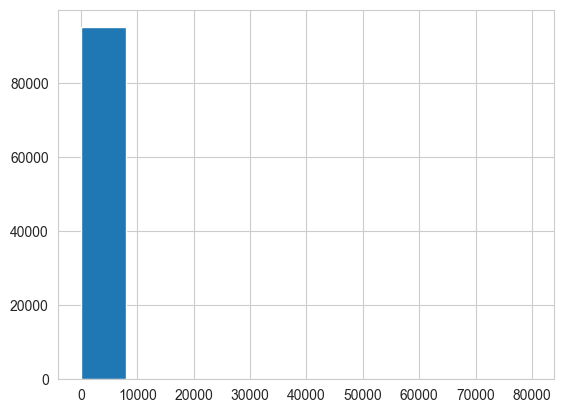

In [244]:
split['price'].hist()

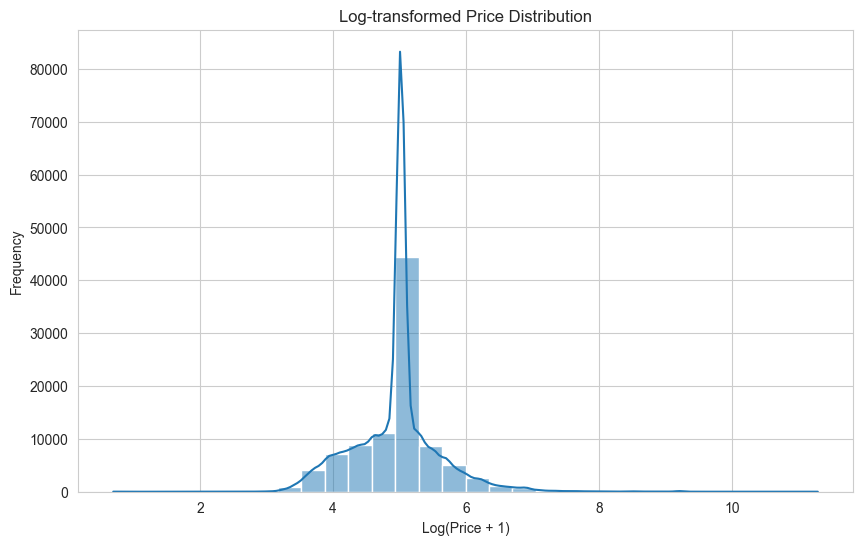

In [245]:
# Apply log transformation to reduce right skewness
split['price'] = np.log1p(split['price'])

# Plot the transformed price distribution
plt.figure(figsize=(10, 6))
sns.histplot(split['price'], bins=30, kde=True)
plt.title('Log-transformed Price Distribution')
plt.xlabel('Log(Price + 1)')
plt.ylabel('Frequency')
plt.show()

<Axes: >

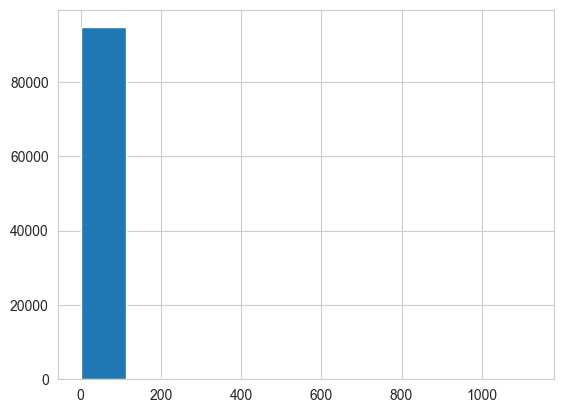

In [246]:
split['minimum_nights'].hist()

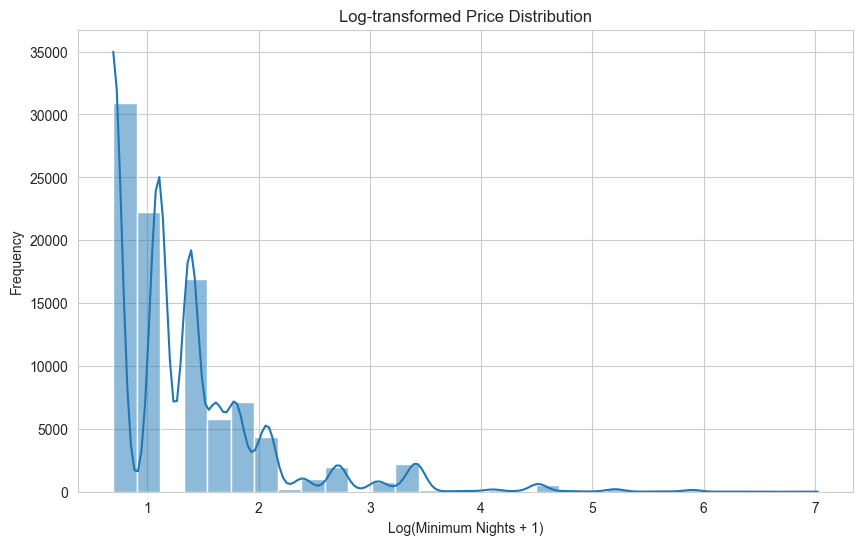

In [247]:
# Apply log transformation to reduce right skewness
split['minimum_nights'] = np.log1p(split['minimum_nights'])

# Plot the transformed price distribution
plt.figure(figsize=(10, 6))
sns.histplot(split['minimum_nights'], bins=30, kde=True)
plt.title('Log-transformed Price Distribution')
plt.xlabel('Log(Minimum Nights + 1)')
plt.ylabel('Frequency')
plt.show()

<Axes: >

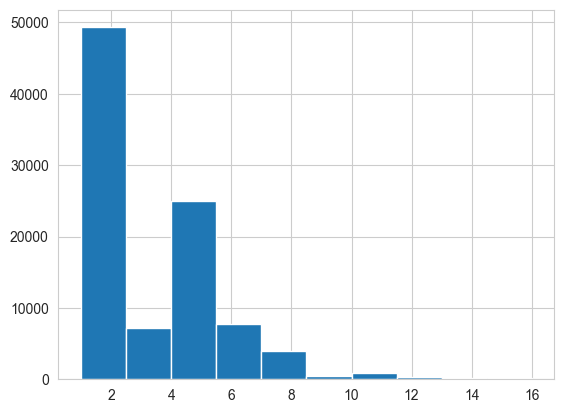

In [248]:
split['accommodates'].hist()

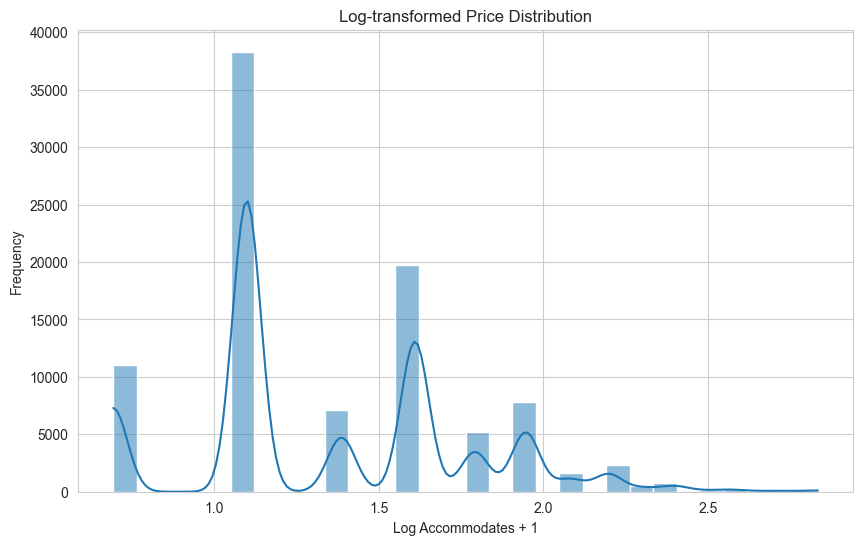

In [249]:
# Apply log transformation to reduce right skewness
split['accommodates'] = np.log1p(split['accommodates'])

# Plot the transformed price distribution
plt.figure(figsize=(10, 6))
sns.histplot(split['accommodates'], bins=30, kde=True)
plt.title('Log-transformed Price Distribution')
plt.xlabel('Log Accommodates + 1')
plt.ylabel('Frequency')
plt.show()

<Axes: >

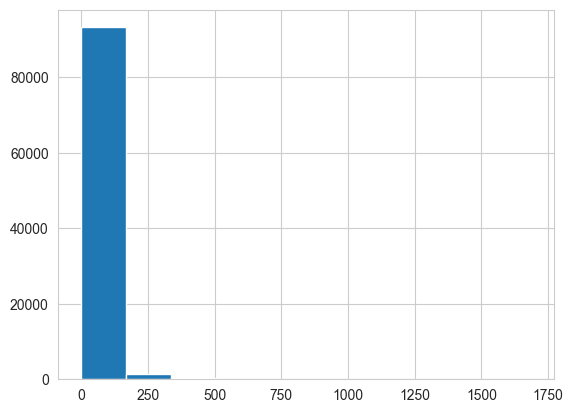

In [250]:
split['number_of_reviews'].hist()

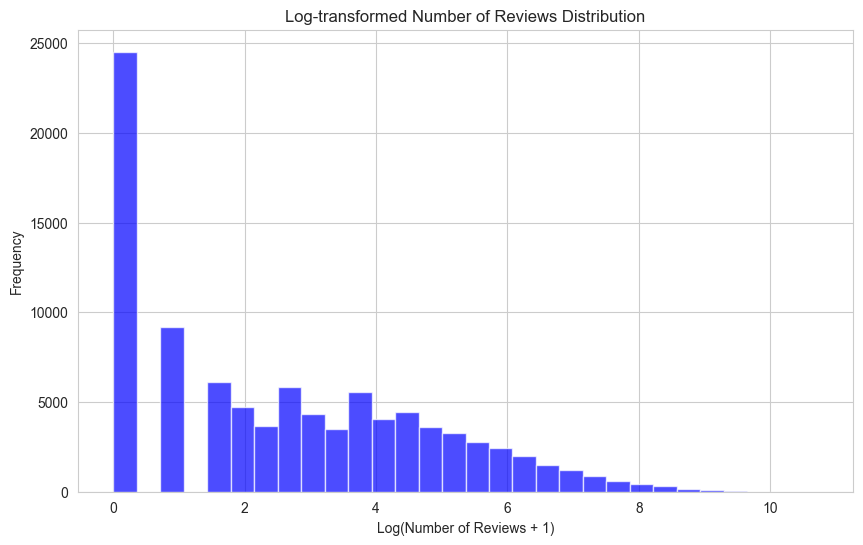

In [251]:
split.loc[:, 'number_of_reviews'] = np.log2(split['number_of_reviews'] + 1)

# Plot the transformed price distribution
plt.figure(figsize=(10, 6))
plt.hist(split['number_of_reviews'], bins=30, color='blue', alpha=0.7)
plt.title('Log-transformed Number of Reviews Distribution')
plt.xlabel('Log(Number of Reviews + 1)')
plt.ylabel('Frequency')
plt.show()

In [252]:
split['bathrooms'] = split['bathrooms'].fillna(0).astype(int)
split['bedrooms'] = split['bedrooms'].fillna(0).astype(int)
split['beds'] = split['beds'].fillna(0).astype(int)

split[['bathrooms', 'bedrooms', 'beds']].head()

,bathrooms,bedrooms,beds
0,1,1,1
1,3,3,3
2,1,1,1
3,1,1,1
4,1,1,1


In [253]:
split.head()

,host_identity_verified,room_type,instant_bookable,minimum_nights,availability_365,accommodates,bathrooms,bedrooms,beds,number_of_reviews,calculated_host_listings_count,price
0,t,Entire home/apt,f,1.791759,22,1.098612,1,1,1,7.189825,11,4.499810
1,t,Entire home/apt,t,0.693147,326,1.945910,3,3,3,7.483816,1,5.398163
2,t,Entire home/apt,f,1.386294,149,1.098612,1,1,1,7.417853,11,4.488636
3,t,Private room,f,1.386294,62,1.098612,1,1,1,7.546894,11,4.330733
4,t,Private room,f,1.386294,363,0.693147,1,1,1,3.807355,1,3.988984


In [254]:
split_num_cols = [['minimum_nights', 'availability_365', 'accommodates', 
                   'number_of_reviews', 'calculated_host_listings_count',
                   'price']]
split_cat_cols = [['host_identity_verified', 'room_type', 'instant_bookable',
                   'bathrooms','bedrooms', 'beds']]
split_num_cols, split_cat_cols

([['minimum_nights',
   'availability_365',
   'accommodates',
   'number_of_reviews',
   'calculated_host_listings_count',
   'price']],
 [['host_identity_verified',
   'room_type',
   'instant_bookable',
   'bathrooms',
   'bedrooms',
   'beds']])

In [255]:
# Perform ordinal encoding on categorical columns
oe = OrdinalEncoder()
split[split_cat_cols[0]] = oe.fit_transform(split[split_cat_cols[0]])

# Perform robust scaling on numerical columns
rs = RobustScaler()
split[split_num_cols[0]] = rs.fit_transform(split[split_num_cols[0]])
split.head()

,host_identity_verified,room_type,instant_bookable,minimum_nights,availability_365,accommodates,bathrooms,bedrooms,beds,number_of_reviews,calculated_host_listings_count,price
0,1.0,0.0,0.0,0.756471,-0.241636,0.000000,1.0,1.0,1.0,1.145946,1.500000,-1.138411
1,1.0,0.0,1.0,-0.442507,0.888476,1.658683,3.0,3.0,3.0,1.215154,-0.166667,0.837925
2,1.0,0.0,0.0,0.313964,0.230483,0.000000,1.0,1.0,1.0,1.199626,1.500000,-1.162992
3,1.0,2.0,0.0,0.313964,-0.092937,0.000000,1.0,1.0,1.0,1.230004,1.500000,-1.510372
4,1.0,2.0,0.0,0.313964,1.026022,-0.793745,1.0,1.0,1.0,0.349683,-0.166667,-2.262205


In [256]:
X = split.drop(columns=['price'])
y = split['price']

# training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, random_state=42)

rfr = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_split=2)

# Fit the model
rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [257]:
# Make predictions
y_pred = rfr.predict(X_test)

# Evaluate the model
rfr_mse = mean_squared_error(y_test, y_pred)
rfr_r2 = r2_score(y_test, y_pred)
rfr_rmse = np.sqrt(rfr_mse)
rfr_mae = mean_absolute_error(y_test, y_pred)
rfr_mape = mean_absolute_percentage_error(y_test, y_pred)

# Print the evaluation metrics
print("Random Forest Regressor")
print("=========================")
print(f"MSE: {rfr_mse:.2f}")
print(f"RMSE: {rfr_rmse:.2f}")
print(f"R2: {rfr_r2:.2f}")
print(f"MAE: {rfr_mae:.2f}")
print(f"MAPE: {rfr_mape:.2f}")

Random Forest Regressor
MSE: 0.80
RMSE: 0.89
R2: 0.59
MAE: 0.53
MAPE: 119962177766009.92


In [258]:
# Define the model
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)


# Fit the model
gbr.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [259]:
# Make predictions
y_pred_gbr = gbr.predict(X_test)
# Evaluate the model
gbr_mse = mean_squared_error(y_test, y_pred_gbr)
gbr_r2 = r2_score(y_test, y_pred_gbr)
gbr_rmse = np.sqrt(gbr_mse)
gbr_mae = mean_absolute_error(y_test, y_pred_gbr)
gbr_mape = mean_absolute_percentage_error(y_test, y_pred_gbr)

# Print the evaluation metrics
print("Gradient Boosting Regressor")
print("=========================")
print(f"MSE: {gbr_mse:.2f}")
print(f"RMSE: {gbr_rmse:.2f}")
print(f"R2: {gbr_r2:.2f}")
print(f"MAE: {gbr_mae:.2f}")
print(f"MAPE: {gbr_mape:.2f}")

Gradient Boosting Regressor
MSE: 0.83
RMSE: 0.91
R2: 0.57
MAE: 0.56
MAPE: 190792046044320.00


In [260]:
# Create a new pipeline with a different model (e.g., Linear Regression)
from sklearn.linear_model import LinearRegression

# Define the model
lr = LinearRegression()

# Fit the model
lr.fit(X_train, y_train)

LinearRegression()

In [261]:
# Make predictions
y_pred_lr = lr.predict(X_test)

# Evaluate the model
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mape = mean_absolute_percentage_error(y_test, y_pred_lr)

# Print the evaluation metrics
print("Linear Regression")
print("=========================")
print(f"MSE: {lr_mse:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R2: {lr_r2:.2f}")
print(f"MAE: {lr_mae:.2f}")
print(f"MAPE: {lr_mape:.2f}")

Linear Regression
MSE: 1.18
RMSE: 1.09
R2: 0.39
MAE: 0.80
MAPE: 904860454774203.38


In [262]:
# Define the model
dtr = DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_split=2)
# Fit the model
dtr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [263]:
# Make predictions
y_pred_dtr = dtr.predict(X_test)
# Evaluate the model
dtr_mse = mean_squared_error(y_test, y_pred_dtr)
dtr_r2 = r2_score(y_test, y_pred_dtr)
dtr_rmse = np.sqrt(dtr_mse)
dtr_mae = mean_absolute_error(y_test, y_pred_dtr)
dtr_mape = mean_absolute_percentage_error(y_test, y_pred_dtr)
# Print the evaluation metrics
print("Decision Tree Regressor")
print("=========================")
print(f"MSE: {dtr_mse:.2f}")
print(f"RMSE: {dtr_rmse:.2f}")
print(f"R2: {dtr_r2:.2f}")
print(f"MAE: {dtr_mae:.2f}")
print(f"MAPE: {dtr_mape:.2f}")

Decision Tree Regressor
MSE: 0.86
RMSE: 0.93
R2: 0.56
MAE: 0.54
MAPE: 124579064100077.61


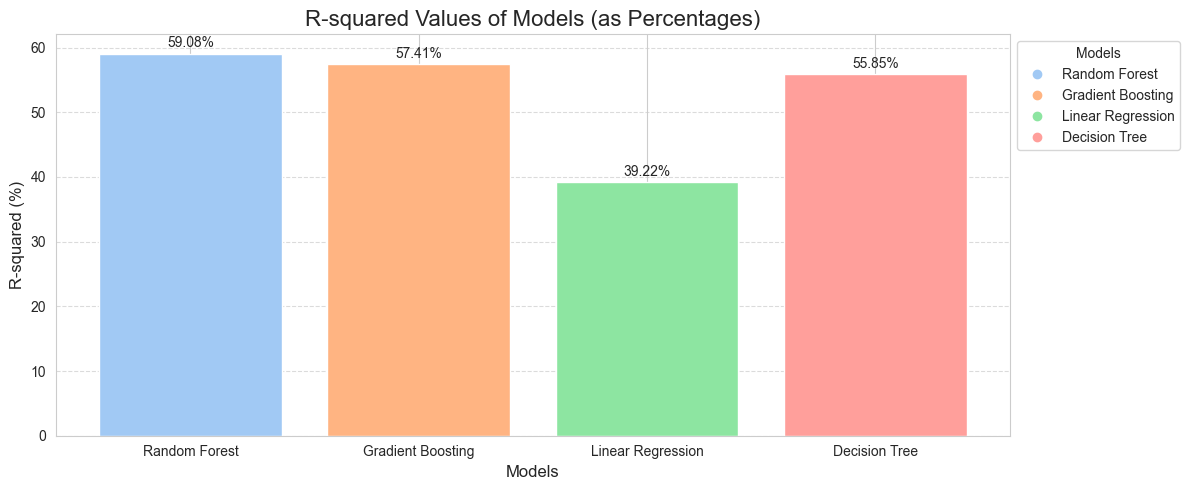

In [264]:
# Define the models and ensure that rfr_sc is defined by computing the score from the Random Forest pipeline if needed
models = ['Random Forest', 'Gradient Boosting', 'Linear Regression', 'Decision Tree']

r_squared_values = [rfr_r2, gbr_r2, lr_r2, dtr_r2]

# Convert R-squared values to percentages
r_squared_percentages = [value * 100 for value in r_squared_values]

# Create the bar chart
plt.figure(figsize=(12, 5))
bars = plt.bar(models, r_squared_percentages, color=sns.color_palette("pastel", len(models)))

# Add labels and title
plt.title('R-squared Values of Models (as Percentages)', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('R-squared (%)', fontsize=12)

# Add percentage labels on top of the bars
for bar, percentage in zip(bars, r_squared_percentages):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{percentage:.2f}%', ha='center', fontsize=10)

# Add a legend outside the chart
handles = [plt.Line2D([0], [0], marker='o', color=bar.get_facecolor(), label=model, linestyle='') 
           for bar, model in zip(bars, models)]
plt.legend(title="Models", handles=handles, loc='upper left', bbox_to_anchor=(1, 1))

# Adjust layout and show the plot
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()